In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from skimage import data, transform

##### System Parameters
For my simulation of the system the Low resolution images would be dependent on certain specifications of the optical setup. For my setup i am taking a low NA objective of say 0.1 NA and a basic magnification factor if 2. I would start with a basic LED array of 7X7 matrix with a 4mm spacing and kept at 20mm below the object. Let my camera pixel size is 6.5um. 

In [11]:
# System Parameters
N = 512                 # Resolution of the simulation grid
na = 0.1                # Objective Numerical Aperture
mag = 2                 # Magnification
wavelength = 0.532e-6   # 532nm (Green LED)
pixel_size_sensor = 6.5e-6 

# LED array parameters
led_gap = 4e-3          # 4mm spacing
led_dist = 80e-3        # 20mm height
array_size = 7         # 7x7 LEDs


In [12]:
#Effective pixel size at the sample plane
pixel_size_eff = pixel_size_sensor / mag  # 3.25um effective pixel
# For simulation, we need a high-res grid that is finer than the LR grid
# Let's assume the HR image has 4x better resolution than the LR limit
pixel_size_hr = pixel_size_eff / 4 


In [13]:
# Create High-Resolution Object
# Amplitude: Cameraman, Phase: Distorted Moon (to simulate biological phase)
amp = transform.resize(data.camera().astype(float), (N, N)) / 255.0
phase = transform.resize(data.moon().astype(float), (N, N)) / 255.0 * np.pi
obj_hr = amp * np.exp(1j * phase)

In [14]:
# Spatial coordinates for the phase factor
x = (np.arange(N) - N//2) * pixel_size_hr
X, Y = np.meshgrid(x, x)

# Fourier coordinates for the Pupil
k_max = 1 / (2 * pixel_size_hr)
k_edge = np.linspace(-k_max, k_max, N)
KX, KY = np.meshgrid(k_edge, k_edge)

In [15]:
# Define the Pupil Function (The Low-Pass Filter)
# The objective lens only passes frequencies up to k_cutoff = NA/lambda
k_cutoff = na / wavelength
pupil = (np.sqrt(KX**2 + KY**2) < k_cutoff).astype(np.complex128)

In [16]:
# LED coordinates
led_idx = np.arange(array_size) - (array_size)// 2
x_led, y_led = np.meshgrid(led_idx * led_gap, led_idx * led_gap)

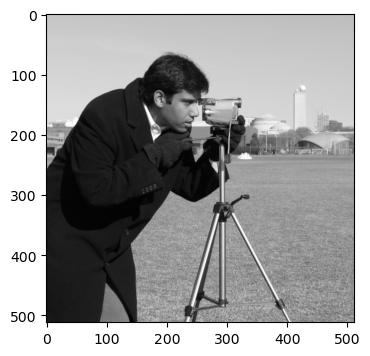

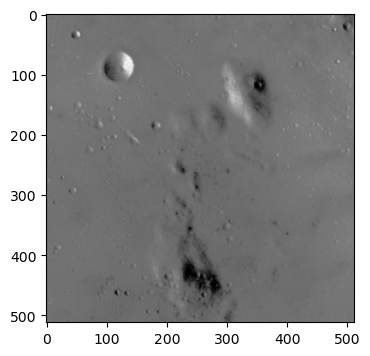

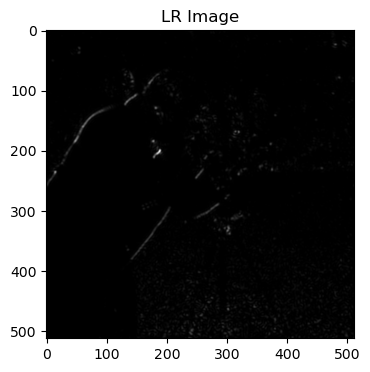

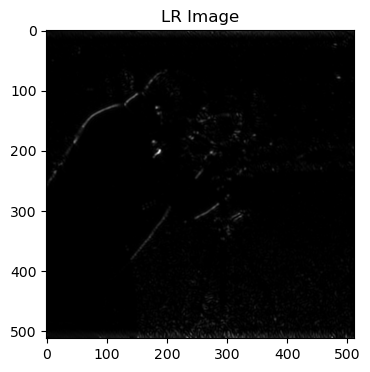

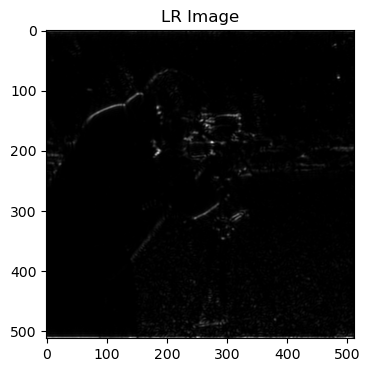

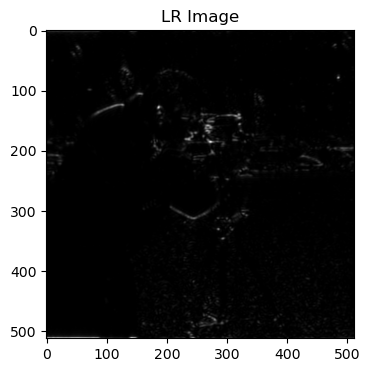

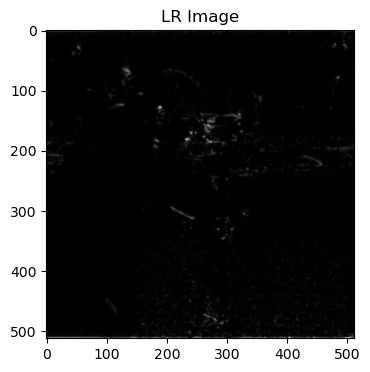

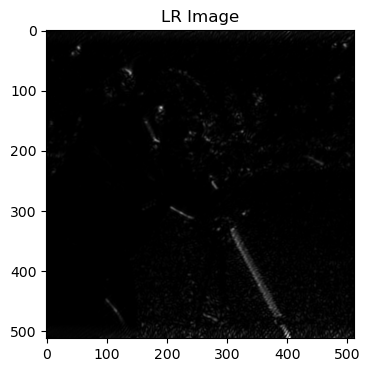

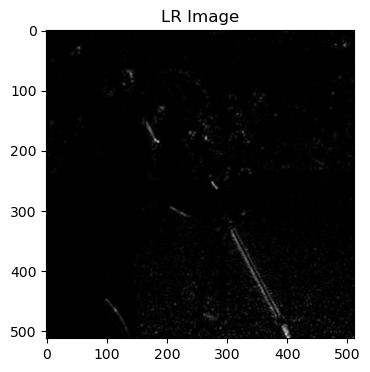

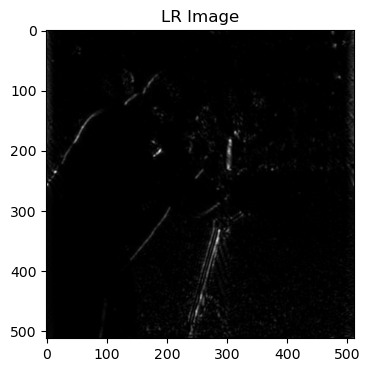

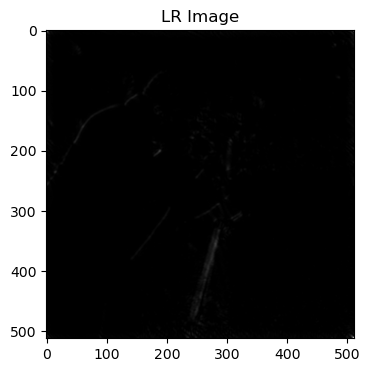

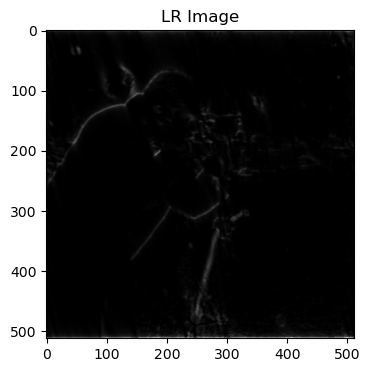

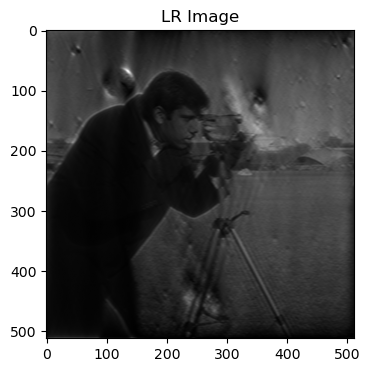

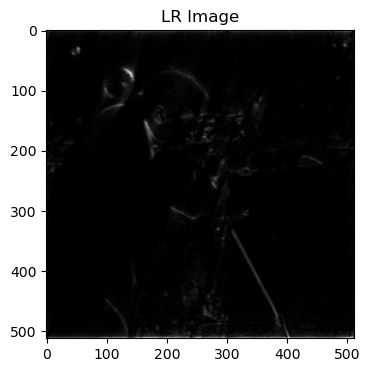

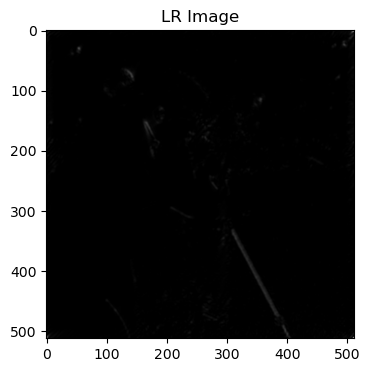

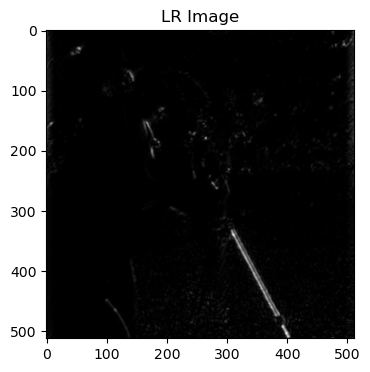

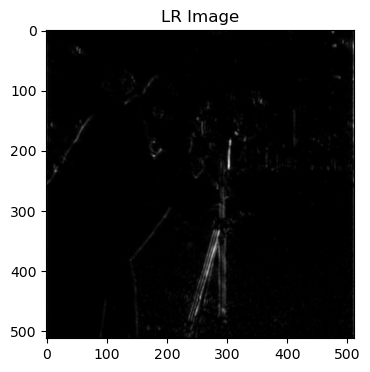

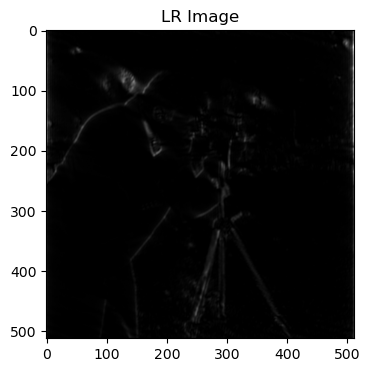

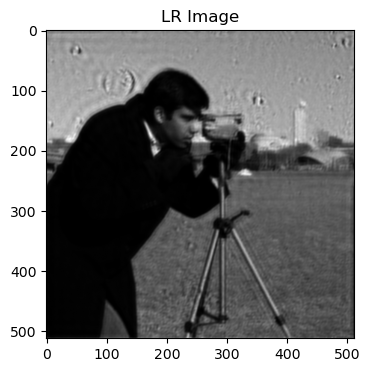

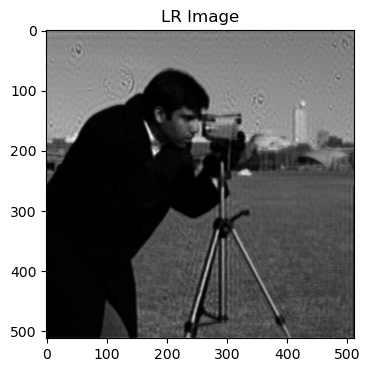

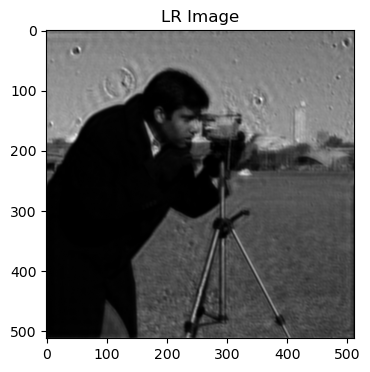

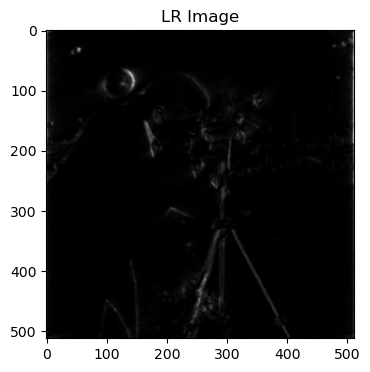

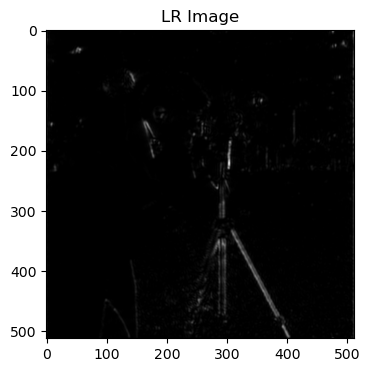

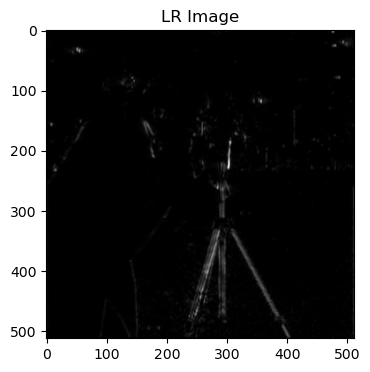

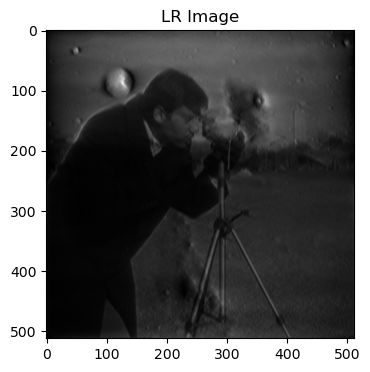

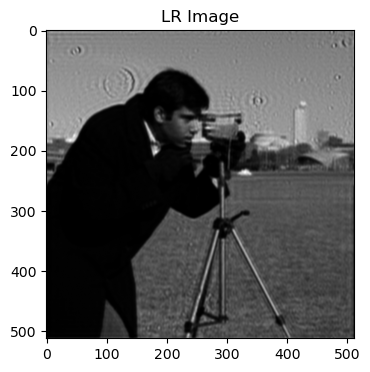

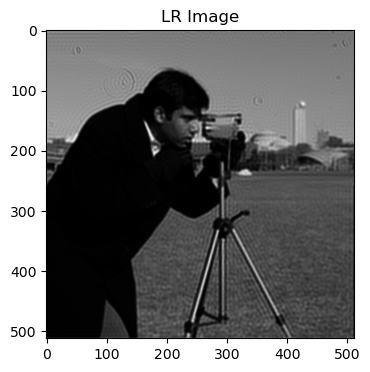

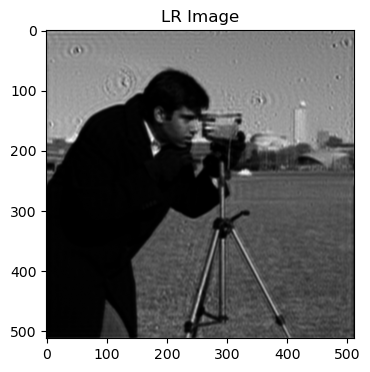

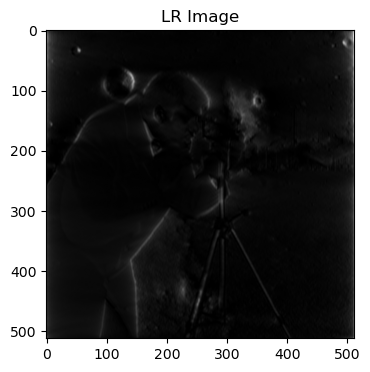

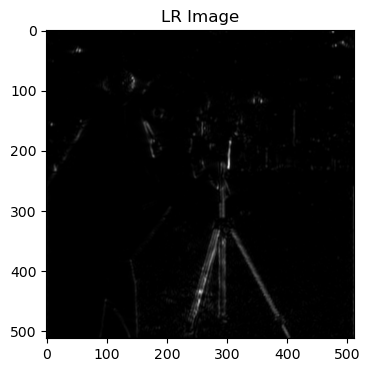

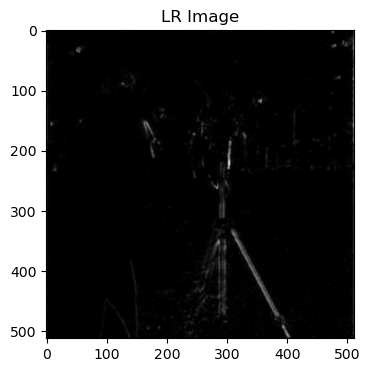

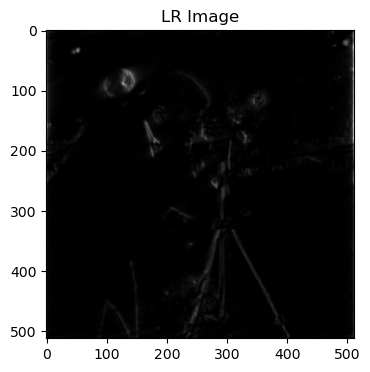

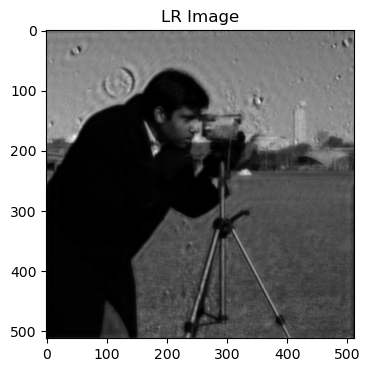

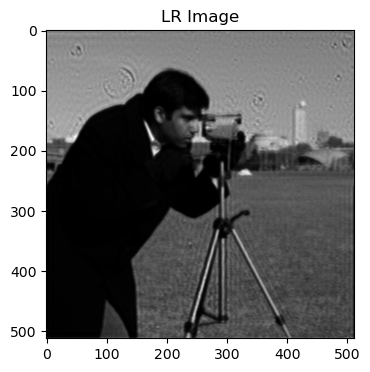

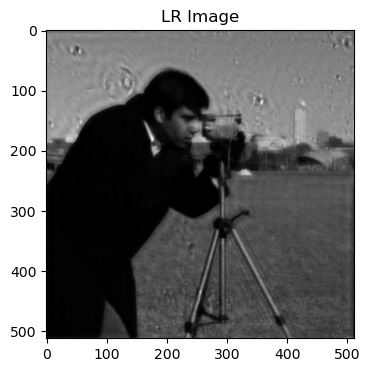

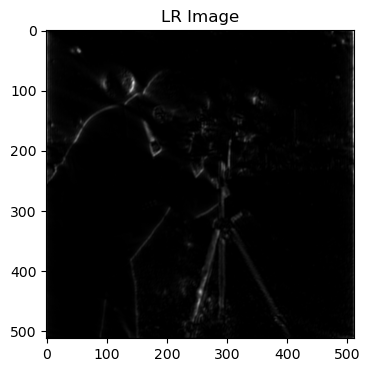

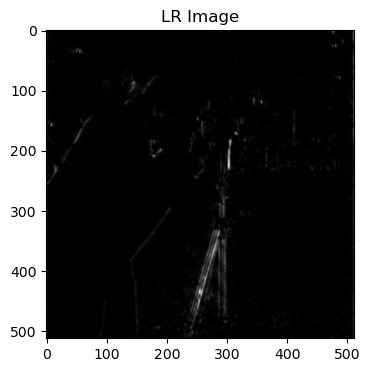

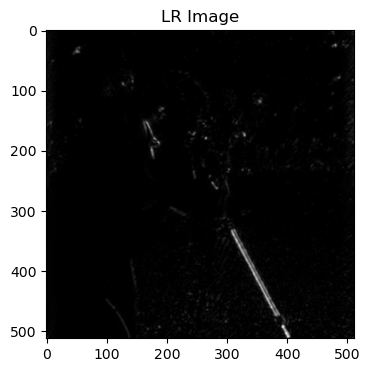

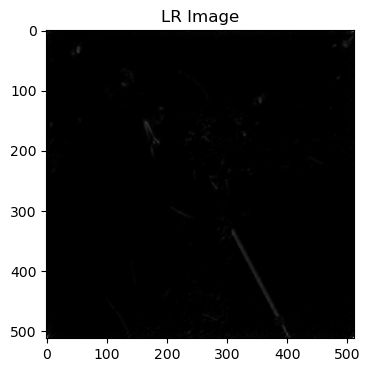

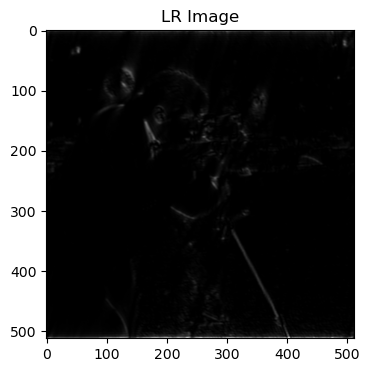

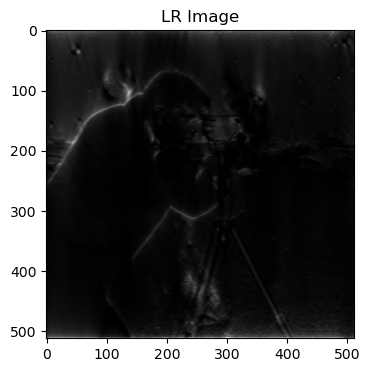

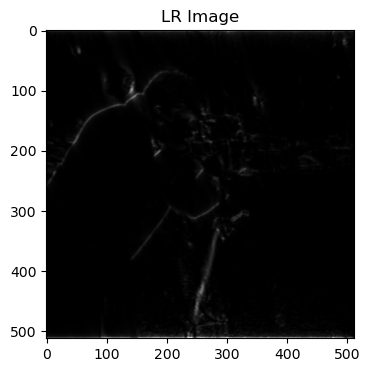

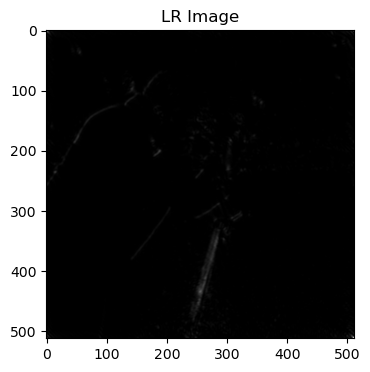

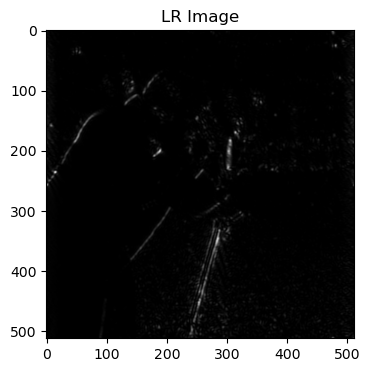

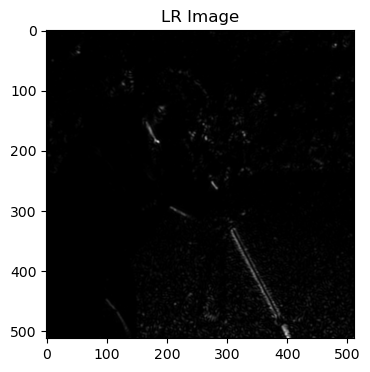

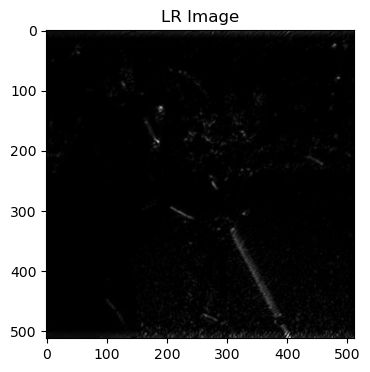

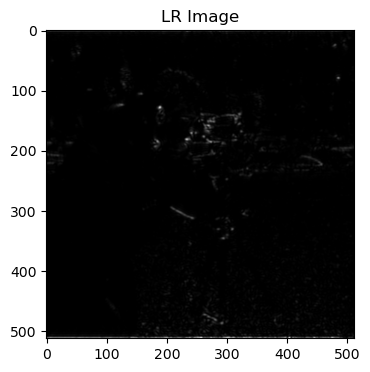

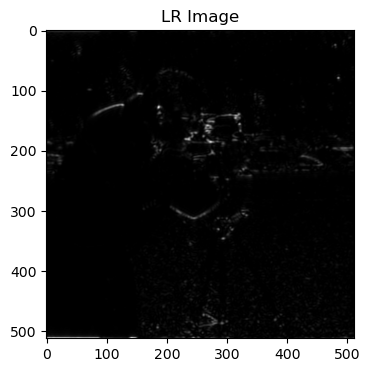

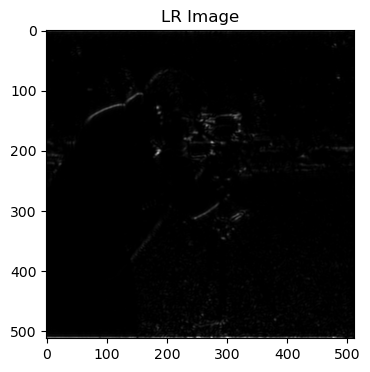

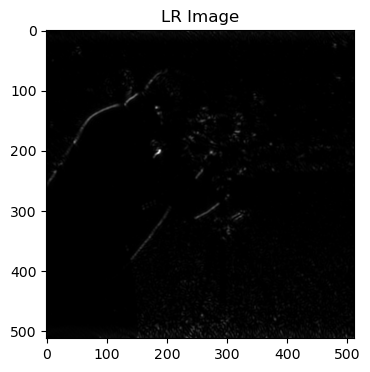

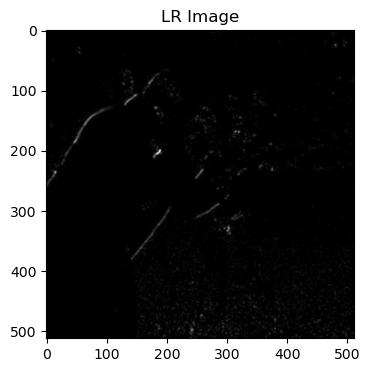

In [20]:
# MAIN SIMULATION BODY
lr_images = []
for i in range(array_size):
    for j in range(array_size):
        # Calculate wavevector for current LED
        r_dist = np.sqrt(x_led[i,j]**2 + y_led[i,j]**2 + led_dist**2)
        kx = (x_led[i,j] / r_dist) / wavelength
        ky = (y_led[i,j] / r_dist) / wavelength
        
        # Apply Linear Phase Factor (Tilted Plane Wave)
        # Shift = exp(j * 2pi * (kx*x + ky*y))
        illumination = np.exp(1j * 2 * np.pi * (kx * X + ky * Y))
        tilted_obj = obj_hr * illumination
        
        # Low-Pass Filter (The Lens)
        obj_fft = fftshift(fft2(ifftshift(tilted_obj)))
        filtered_fft = obj_fft * pupil
        
        # Inverse FFT to get Low-Res Field
        lr_field = fftshift(ifft2(ifftshift(filtered_fft)))
        
        # Detect Intensity (What the camera sees)
        # We downsample the intensity to simulate the lower resolution of the camera
        intensity = np.abs(lr_field)**2
        lr_images.append(intensity)

plt.figure(figsize=(12, 4))
plt.imshow(np.abs(obj_hr), cmap='gray')
plt.show()

plt.figure(figsize=(12, 4))
plt.imshow(np.angle(obj_hr), cmap='gray')
plt.show()

for i in range(0,49):
    plt.figure(figsize=(12, 4))
    plt.imshow(lr_images[i], cmap='gray'); plt.title("LR Image")
    plt.show()